In [1]:
# [설치] FAISS(벡터 검색), datasets, NLLB 토크나이저용 sentencepiece, 데모용 gradio
!pip install -q faiss-cpu datasets sentencepiece gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 46.6 MB/s eta 0:00:00


In [2]:
# [환경] 라이브러리 import + 구글 드라이브 연결
# 결과(results)와 캐시(cache)를 드라이브에 저장해서 런타임이 끊겨도 다시 계산하지 않게 함
import os, gc, json
import numpy as np
import pandas as pd
import torch
import faiss
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoProcessor, AutoModel, pipeline

from google.colab import drive
drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/DRAG/week5"
RESULT_DIR = f"{BASE}/results"
CACHE_DIR = f"{BASE}/cache"
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

Mounted at /content/drive
device: cuda


In [3]:
# [폰트] 그래프 제목에 한글이 깨지지 않도록 나눔고딕 설치
!apt-get -qq install -y fonts-nanum > /dev/null
import matplotlib.font_manager as fm
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

In [4]:
# [데이터] Flickr8k test split 1,000장 불러오기 (이미지당 영어 캡션 5개)
ds = load_dataset("jxie/flickr8k", split="test")
N_IMAGES = len(ds)
caption_cols = [c for c in ds.column_names if c.startswith("caption")]
print(ds)
print("이미지 수:", N_IMAGES, "/ 캡션 컬럼:", caption_cols)

images = [img.convert("RGB") for img in ds["image"]]
captions = {c: ds[c] for c in caption_cols}

README.md:   0%|          | 0.00/687 [00:00<?, ?B/s]

data/train-00000-of-00002-2f8f6bfa852eac(…): reconstructing file:   0%|          |  0.00B /  414MB            

data/train-00000-of-00002-2f8f6bfa852eac(…): downloading bytes:           |  0.00B            

data/train-00001-of-00002-2173151d8cd6c7(…): reconstructing file:   0%|          |  0.00B /  414MB            

data/train-00001-of-00002-2173151d8cd6c7(…): downloading bytes:           |  0.00B            

...

data/test-00000-of-00001-42a2661d12c73e4(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4'],
    num_rows: 1000
})
이미지 수: 1000 / 캡션 컬럼: ['caption_0', 'caption_1', 'caption_2', 'caption_3', 'caption_4']


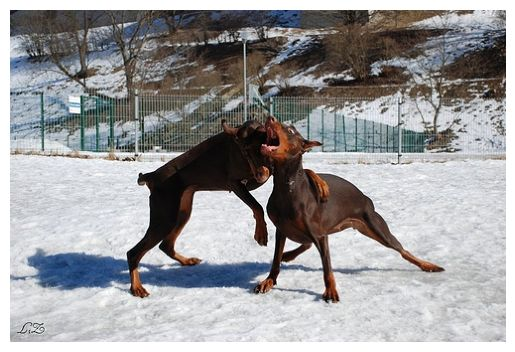

- The dogs are in the snow in front of a fence .
- The dogs play on the snow .
- Two brown dogs playfully fight in the snow .
- Two brown dogs wrestle in the snow .
- Two dogs playing in the snow .


In [5]:
# 첫 번째 이미지와 캡션 5개 확인
plt.imshow(images[0]); plt.axis("off"); plt.show()
for c in caption_cols:
    print("-", captions[c][0])

In [6]:
%%time
# [번역] 영어 캡션(caption_0)을 NLLB로 한국어 번역 → 한국어 질의 평가용
# pipeline이 버전 문제로 안 돌아가서 모델을 직접 불러오고 forced_bos_token_id로 출력 언어를 한국어로 고정
# 한 번 번역하면 드라이브에 저장하고 다음부터는 불러오기만 함
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

KO_PATH = f"{CACHE_DIR}/captions_ko.json"

if os.path.exists(KO_PATH):
    captions_ko = json.load(open(KO_PATH, encoding="utf-8"))
else:
    MT_ID = "facebook/nllb-200-distilled-600M"
    mt_tok = AutoTokenizer.from_pretrained(MT_ID, src_lang="eng_Latn")
    mt_model = AutoModelForSeq2SeqLM.from_pretrained(
        MT_ID, torch_dtype=torch.float16 if device == "cuda" else torch.float32
    ).to(device).eval()
    ko_token_id = mt_tok.convert_tokens_to_ids("kor_Hang")

    captions_ko = []
    src = captions["caption_0"]
    BS = 32
    with torch.no_grad():
        for i in range(0, len(src), BS):
            batch = mt_tok(src[i:i + BS], return_tensors="pt", padding=True, truncation=True).to(device)
            gen = mt_model.generate(
                **batch,
                forced_bos_token_id=ko_token_id,
                max_new_tokens=128,
                num_beams=4,
            )
            captions_ko += mt_tok.batch_decode(gen, skip_special_tokens=True)
            if (i // BS) % 5 == 0:
                print(f"{min(i + BS, len(src))}/{len(src)}")

    json.dump(captions_ko, open(KO_PATH, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
    del mt_model, mt_tok; gc.collect(); torch.cuda.empty_cache()

for en, ko in list(zip(captions["caption_0"], captions_ko))[:5]:
    print(en, "\n →", ko, "\n")

The dogs are in the snow in front of a fence . 
 → 개들은 울타리 앞에서 눈이 내리고 있습니다 . 

a brown and white dog swimming towards some in the pool 
 → 갈색과 흰색의 개가 수영장에서 어느 쪽으로 수영하고 있습니다. 

A man and a woman in festive costumes dancing . 
 → 축제복을 입고 춤추는 남자와 여자가 

A couple of people sit outdoors at a table with an umbrella and talk . 
 → 두 사람은 우산을 들고 야외에서 테이블에 앉아 대화를 나누고 있습니다 . 

A man is wearing a Sooners red football shirt and helmet . 
 → 스너즈의 빨간색 셔츠와 헬멧을 입고 있는 남자 

CPU times: user 21.9 ms, sys: 190 µs, total: 22.1 ms
Wall time: 938 ms


In [7]:
# [모델] 비교할 SigLIP 모델 3개 + 이미지/텍스트 임베딩 함수
# - FAISS는 float32만 받아서 float32로 로드
# - 텍스트는 padding="max_length", max_length=64 필수 (SigLIP 학습 방식)
# - 임베딩을 L2 정규화 → 내적 = 코사인 유사도
MODELS = {
    "siglip-base-multilingual": "google/siglip-base-patch16-256-multilingual",
    "siglip2-base":             "google/siglip2-base-patch16-256",
    "siglip2-so400m":           "google/siglip2-so400m-patch14-384",
}

model, processor, CUR = None, None, None

def load_model(name):
    global model, processor, CUR
    if CUR == name:
        return
    if model is not None:
        del model; gc.collect(); torch.cuda.empty_cache()
    model_id = MODELS[name]
    model = AutoModel.from_pretrained(model_id, torch_dtype=torch.float32).to(device).eval()
    processor = AutoProcessor.from_pretrained(model_id)
    CUR = name
    print("loaded:", model_id)

def _to_tensor(out):
    return out if torch.is_tensor(out) else out.pooler_output

def to_faiss(vec):
    vec = np.ascontiguousarray(vec.detach().float().cpu().numpy())
    faiss.normalize_L2(vec)   # 정규화 후 내적 = 코사인 유사도
    return vec

@torch.no_grad()
def embed_images(imgs, batch_size=32):
    vecs = []
    for i in range(0, len(imgs), batch_size):
        inputs = processor(images=imgs[i:i + batch_size], return_tensors="pt").to(device)
        vecs.append(to_faiss(_to_tensor(model.get_image_features(**inputs))))
    return np.concatenate(vecs)

@torch.no_grad()
def embed_texts(texts, batch_size=64):
    texts = [t.lower() for t in texts]   # SigLIP2는 소문자로 학습됨
    vecs = []
    for i in range(0, len(texts), batch_size):
        inputs = processor(
            text=texts[i:i + batch_size],
            padding="max_length", max_length=64, truncation=True,   # SigLIP은 꼭 max_length padding
            return_tensors="pt",
        ).to(device)
        vecs.append(to_faiss(_to_tensor(model.get_text_features(**inputs))))
    return np.concatenate(vecs)

In [8]:
# [인덱싱] 모델별로 이미지 1,000장을 임베딩해서 FAISS 인덱스(IndexFlatIP)에 저장
# 인덱스 파일이 드라이브에 있으면 다시 계산하지 않고 불러옴
import time

def build_index(name):
    path = f"{CACHE_DIR}/{name}.index"
    if os.path.exists(path):
        return faiss.read_index(path)
    vecs = embed_images(images)
    idx = faiss.IndexFlatIP(vecs.shape[1])
    idx.add(vecs)
    faiss.write_index(idx, path)
    return idx

indexes = {}
for name in MODELS:
    load_model(name)
    t = time.time()
    indexes[name] = build_index(name)
    print(f"{name}: dim={indexes[name].d}, ntotal={indexes[name].ntotal}, {time.time()-t:.1f}s\n")

config.json:   0%|          | 0.00/348 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.48GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.2k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

loaded: google/siglip2-so400m-patch14-384
siglip2-so400m: dim=1152, ntotal=1000, 0.8s



In [9]:
# [평가] Recall@K: 캡션으로 검색했을 때 원래 이미지가 상위 K장 안에 든 비율
# 모델 3개 × (영어 caption_0 / 영어 캡션 5개 전부 / 한국어 번역 caption_0)
KS = (1, 5, 10)

def recall_at_k(index, queries, gt_ids, ks=KS):
    _, ids = index.search(embed_texts(queries), max(ks))
    gt = np.asarray(gt_ids)[:, None]
    return {f"R@{k}": float((ids[:, :k] == gt).any(axis=1).mean()) for k in ks}

all_q, all_gt = [], []
for c in caption_cols:
    all_q += captions[c]
    all_gt += list(range(N_IMAGES))

rows = []
for name in MODELS:
    load_model(name)
    idx = indexes[name]
    rows.append({"model": name, "query": "EN caption_0", **recall_at_k(idx, captions["caption_0"], range(N_IMAGES))})
    rows.append({"model": name, "query": "EN all 5",     **recall_at_k(idx, all_q, all_gt)})
    rows.append({"model": name, "query": "KO caption_0", **recall_at_k(idx, captions_ko, range(N_IMAGES))})

recall_df = pd.DataFrame(rows)
recall_df.to_csv(f"{RESULT_DIR}/recall_at_k.csv", index=False)
recall_df.style.format({c: "{:.3f}" for c in ["R@1", "R@5", "R@10"]})

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

loaded: google/siglip-base-patch16-256-multilingual


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

loaded: google/siglip2-base-patch16-256


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

loaded: google/siglip2-so400m-patch14-384


,model,query,R@1,R@5,R@10
0,siglip-base-multilingual,EN caption_0,0.699,0.915,0.966
1,siglip-base-multilingual,EN all 5,0.702,0.914,0.960
2,siglip-base-multilingual,KO caption_0,0.434,0.685,0.774
3,siglip2-base,EN caption_0,0.769,0.948,0.982
4,siglip2-base,EN all 5,0.770,0.945,0.977
5,siglip2-base,KO caption_0,0.450,0.693,0.779
6,siglip2-so400m,EN caption_0,0.816,0.956,0.987
7,siglip2-so400m,EN all 5,0.812,0.957,0.985
8,siglip2-so400m,KO caption_0,0.541,0.768,0.851


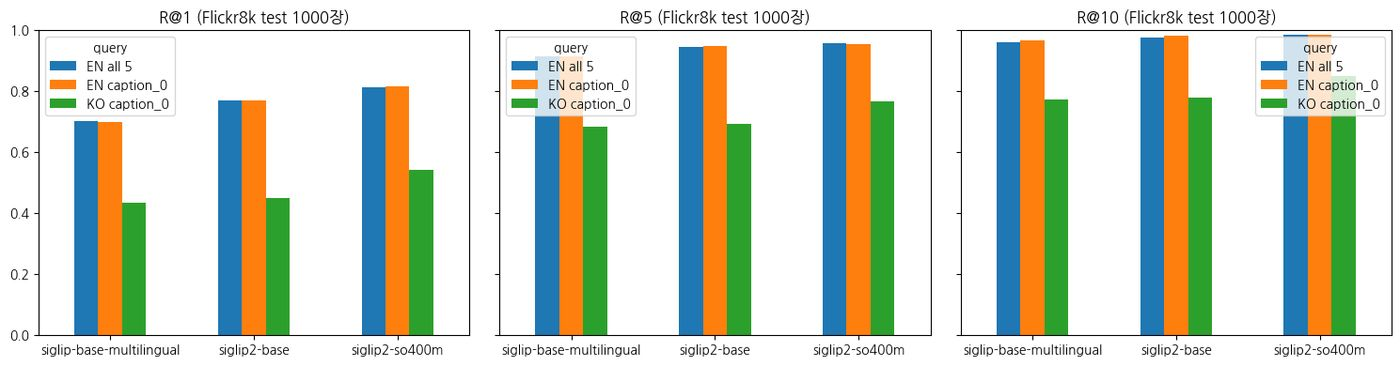

In [10]:
# Recall@1/5/10을 모델별 막대그래프로 비교하고 저장
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, k in zip(axes, ["R@1", "R@5", "R@10"]):
    pv = recall_df.pivot(index="model", columns="query", values=k).loc[list(MODELS)]
    pv.plot.bar(ax=ax, rot=0)
    ax.set_title(f"{k} (Flickr8k test {N_IMAGES}장)")
    ax.set_ylim(0, 1); ax.set_xlabel("")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/recall_compare.png", dpi=120, bbox_inches="tight")
plt.show()

In [11]:
# [검색] 영어 R@5가 가장 높은 모델로 텍스트 → 상위 k장 검색하고 결과를 이미지로 저장
BEST = (recall_df[recall_df["query"] == "EN caption_0"]
        .sort_values("R@5", ascending=False).iloc[0]["model"])
print("데모 모델:", BEST)
load_model(BEST)
index = indexes[BEST]

def search(query, k=5):
    scores, ids = index.search(embed_texts([query]), k)
    return scores[0], ids[0]

def show_results(query, k=5, save=True):
    scores, ids = search(query, k)
    fig, axes = plt.subplots(1, k, figsize=(3.2 * k, 3.8))
    for ax, s, i in zip(axes, scores, ids):
        ax.imshow(images[int(i)])
        ax.set_title(f"#{int(i)}  sim={s:.3f}", fontsize=9)
        ax.axis("off")
    fig.suptitle(f"[{BEST}] {query}", fontsize=12)
    plt.tight_layout()
    if save:
        fname = query.replace(" ", "_").replace("/", "_")[:40]
        fig.savefig(f"{RESULT_DIR}/search_{fname}.png", dpi=120, bbox_inches="tight")
    plt.show()
    return ids

데모 모델: siglip2-so400m


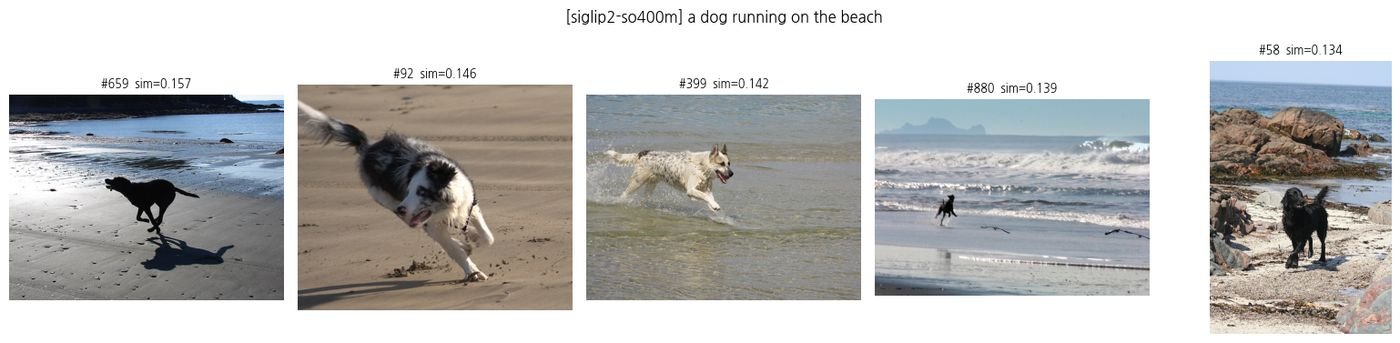

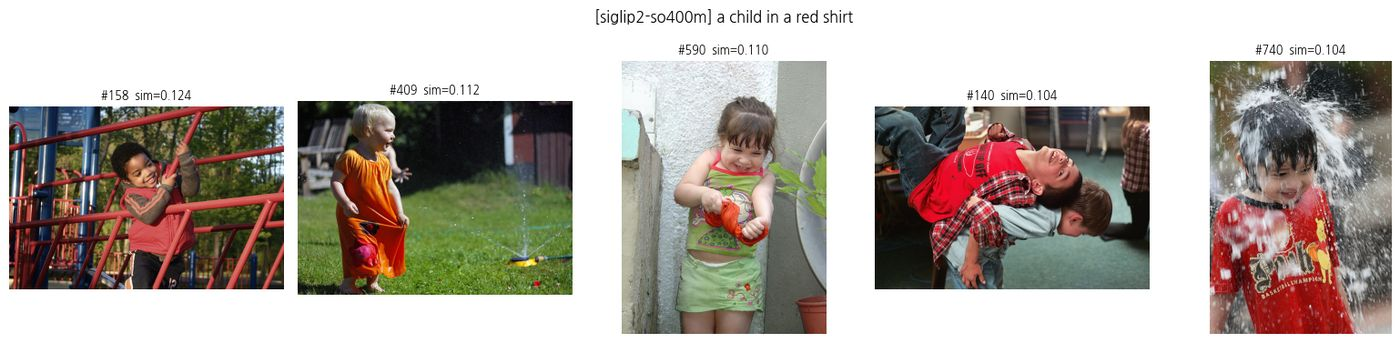

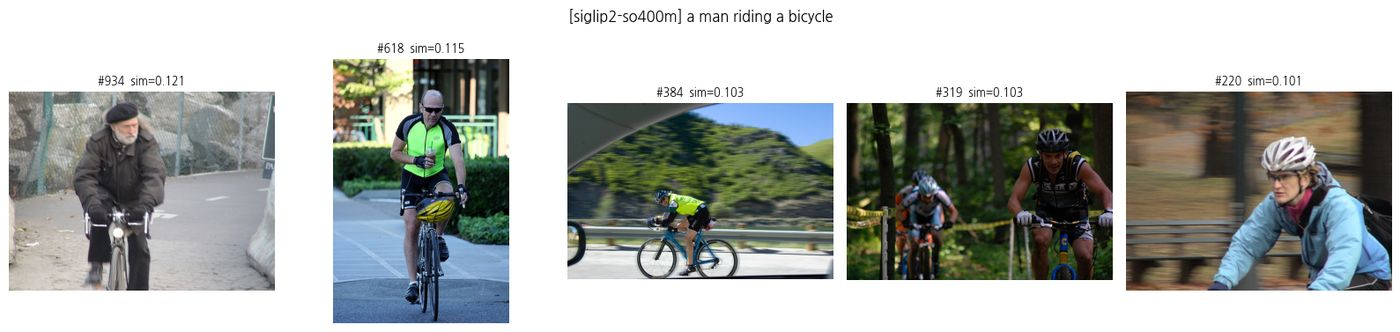

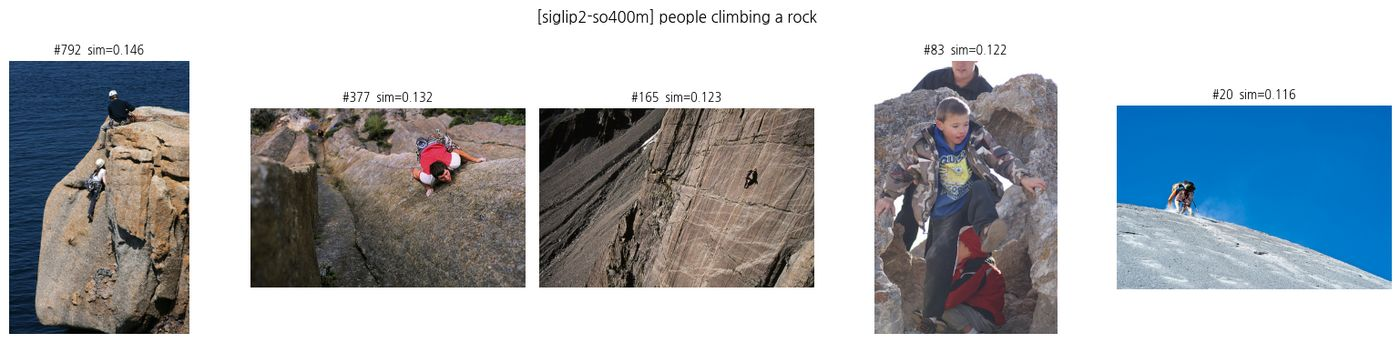

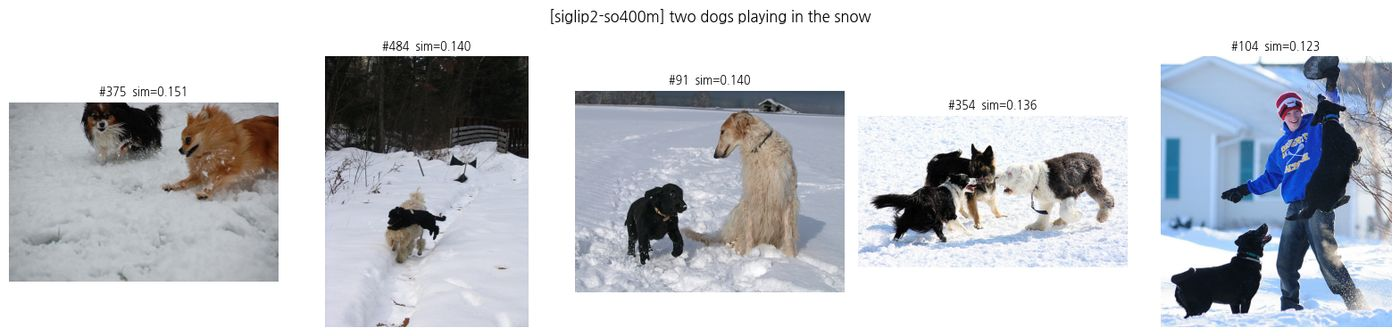

In [12]:
# 영어 질의 검색 결과 (한국어 질의 결과는 맨 아래 [추가] 셀)
en_queries = [
    "a dog running on the beach",
    "a child in a red shirt",
    "a man riding a bicycle",
    "people climbing a rock",
    "two dogs playing in the snow",
]
for q in en_queries:
    show_results(q)

In [13]:
%%time
# [역번역] 한국어 캡션을 다시 영어로 번역 → "한국어 질의를 영어로 바꿔서 검색"하는 방식 실험용
KO2EN_PATH = f"{CACHE_DIR}/captions_ko2en.json"

if os.path.exists(KO2EN_PATH):
    captions_ko2en = json.load(open(KO2EN_PATH, encoding="utf-8"))
else:
    MT_ID = "facebook/nllb-200-distilled-600M"
    mt_tok = AutoTokenizer.from_pretrained(MT_ID, src_lang="kor_Hang")
    mt_model = AutoModelForSeq2SeqLM.from_pretrained(
        MT_ID, torch_dtype=torch.float16 if device == "cuda" else torch.float32
    ).to(device).eval()
    en_token_id = mt_tok.convert_tokens_to_ids("eng_Latn")

    captions_ko2en = []
    BS = 32
    with torch.no_grad():
        for i in range(0, len(captions_ko), BS):
            batch = mt_tok(captions_ko[i:i + BS], return_tensors="pt", padding=True, truncation=True).to(device)
            gen = mt_model.generate(**batch, forced_bos_token_id=en_token_id, max_new_tokens=128, num_beams=4)
            captions_ko2en += mt_tok.batch_decode(gen, skip_special_tokens=True)
            if (i // BS) % 5 == 0:
                print(f"{min(i + BS, len(captions_ko))}/{len(captions_ko)}")

    json.dump(captions_ko2en, open(KO2EN_PATH, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
    del mt_model, mt_tok; gc.collect(); torch.cuda.empty_cache()

for en, ko, back in list(zip(captions["caption_0"], captions_ko, captions_ko2en))[:5]:
    print("원문 :", en); print("한국어:", ko); print("재번역:", back, "\n")

원문 : The dogs are in the snow in front of a fence .
한국어: 개들은 울타리 앞에서 눈이 내리고 있습니다 .
재번역: The dogs are snowing in front of the fence. 

원문 : a brown and white dog swimming towards some in the pool
한국어: 갈색과 흰색의 개가 수영장에서 어느 쪽으로 수영하고 있습니다.
재번역: Brown and white dogs are swimming in either direction of the pool. 

원문 : A man and a woman in festive costumes dancing .
한국어: 축제복을 입고 춤추는 남자와 여자가
재번역: A man and a woman dancing in festive costumes. 

원문 : A couple of people sit outdoors at a table with an umbrella and talk .
한국어: 두 사람은 우산을 들고 야외에서 테이블에 앉아 대화를 나누고 있습니다 .
재번역: They're sitting at a table outdoors, holding a chair and having a conversation. 

원문 : A man is wearing a Sooners red football shirt and helmet .
한국어: 스너즈의 빨간색 셔츠와 헬멧을 입고 있는 남자
재번역: The man in Snares' red shirt and helmet. 

CPU times: user 20.4 ms, sys: 921 µs, total: 21.3 ms
Wall time: 472 ms


In [14]:
# 질의 넣는 방식 비교 (R@1): 영어 원문 / 한국어 직접 / 한국어 → 영어 번역 후 검색
rows2 = []
for name in MODELS:
    load_model(name)
    idx = indexes[name]
    rows2.append({"model": name, "query": "EN 원문",           **recall_at_k(idx, captions["caption_0"], range(N_IMAGES))})
    rows2.append({"model": name, "query": "KO 직접 검색",       **recall_at_k(idx, captions_ko, range(N_IMAGES))})
    rows2.append({"model": name, "query": "KO→EN 번역 후 검색", **recall_at_k(idx, captions_ko2en, range(N_IMAGES))})

route_df = pd.DataFrame(rows2)
route_df.to_csv(f"{RESULT_DIR}/recall_ko_route.csv", index=False)
display(route_df.pivot(index="model", columns="query", values="R@1").loc[list(MODELS)].round(3))
load_model(BEST)

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

loaded: google/siglip-base-patch16-256-multilingual


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

loaded: google/siglip2-base-patch16-256


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

loaded: google/siglip2-so400m-patch14-384


query,EN 원문,KO 직접 검색,KO→EN 번역 후 검색
model,,,
siglip-base-multilingual,0.699,0.434,0.543
siglip2-base,0.769,0.450,0.593
siglip2-so400m,0.816,0.541,0.633


In [15]:
# [질의 합치기] 한국어 임베딩과 역번역 영어 임베딩을 alpha 비율로 섞어서 검색
# alpha=0이면 한국어만, 1이면 번역문만
def recall_from_sim(sim, ks=KS):
    # sim: (질의 수, 이미지 수), i번째 질의의 정답 = i번째 이미지
    topk = np.argsort(-sim, axis=1)[:, :max(ks)]
    gt = np.arange(sim.shape[0])[:, None]
    return {f"R@{k}": float((topk[:, :k] == gt).any(axis=1).mean()) for k in ks}

img_vecs = {name: indexes[name].reconstruct_n(0, indexes[name].ntotal) for name in MODELS}

ALPHAS = [0.0, 0.3, 0.5, 0.7, 1.0]   # 0 = KO만, 1 = KO→EN만
q_cache = {}
rows3 = []
for name in MODELS:
    load_model(name)
    q_ko   = embed_texts(captions_ko)
    q_back = embed_texts(captions_ko2en)
    q_cache[name] = (q_ko, q_back)
    for a in ALPHAS:
        q = (1 - a) * q_ko + a * q_back
        faiss.normalize_L2(q)
        rows3.append({"model": name, "alpha": a, **recall_from_sim(q @ img_vecs[name].T)})

fusion_df = pd.DataFrame(rows3)
fusion_df.to_csv(f"{RESULT_DIR}/recall_query_fusion.csv", index=False)
display(fusion_df.pivot(index="alpha", columns="model", values="R@1")[list(MODELS)].round(3))
load_model(BEST)

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

loaded: google/siglip-base-patch16-256-multilingual


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

loaded: google/siglip2-base-patch16-256


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

loaded: google/siglip2-so400m-patch14-384


model,siglip-base-multilingual,siglip2-base,siglip2-so400m
alpha,,,
0.0,0.434,0.450,0.541
0.3,0.509,0.553,0.630
0.5,0.550,0.592,0.652
0.7,0.564,0.607,0.648
1.0,0.543,0.593,0.633


In [16]:
# [앙상블] 여러 모델의 유사도 점수를 더해서 검색 → so400m 단독보다 나아지는지 확인
def sim_of(name, alpha):
    q_ko, q_back = q_cache[name]
    q = (1 - alpha) * q_ko + alpha * q_back
    faiss.normalize_L2(q)
    return q @ img_vecs[name].T

best_alpha = 0.5   # 위 질의 합치기 결과에서 so400m이 가장 좋았던 값

# 앙상블에 쓸 모델 이름 목록
model_names = ["siglip-base-multilingual", "siglip2-base", "siglip2-so400m"]

combos = {
    "so400m 단독":            {"siglip2-so400m": 1.0},
    "so400m + siglip2-base":  {"siglip2-so400m": 0.5, "siglip2-base": 0.5},
    "so400m + v1":            {"siglip2-so400m": 0.5, "siglip-base-multilingual": 0.5},
    "세 모델 전부":            {n: 1/3 for n in model_names},
}

rows4 = []
for label, weights in combos.items():
    sim = sum(w * sim_of(n, best_alpha) for n, w in weights.items())
    rows4.append({"combo": label, **recall_from_sim(sim)})

ens_df = pd.DataFrame(rows4)
ens_df.to_csv(f"{RESULT_DIR}/recall_ensemble_ko.csv", index=False)
display(ens_df.round(3))

,combo,R@1,R@5,R@10
0,so400m 단독,0.652,0.858,0.931
1,so400m + siglip2-base,0.661,0.871,0.938
2,so400m + v1,0.646,0.866,0.920
3,세 모델 전부,0.652,0.871,0.929


In [17]:
# [파인튜닝 준비] 검색용 모델을 메모리에서 내리고, Flickr8k train(6,000장)/validation(1,000장) 불러오기
# 파인튜닝 대상: siglip2-base, 시드 42로 고정
import random
import torch.nn.functional as F
from transformers import get_cosine_schedule_with_warmup

# 앞에서 올려둔 검색용 모델은 메모리에서 내림
if model is not None:
    del model
model, processor, CUR = None, None, None
gc.collect(); torch.cuda.empty_cache()

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

FT_NAME = "siglip2-base"
FT_ID = MODELS[FT_NAME]
MT_ID = "facebook/nllb-200-distilled-600M"
FT_DIR = f"{BASE}/finetune"
os.makedirs(FT_DIR, exist_ok=True)

ds_train = load_dataset("jxie/flickr8k", split="train")
ds_val = load_dataset("jxie/flickr8k", split="validation")
print("train:", len(ds_train), "/ val:", len(ds_val))

def recall_from_sim(sim, ks=KS):
    topk = np.argsort(-sim, axis=1)[:, :max(ks)]
    gt = np.arange(sim.shape[0])[:, None]
    return {f"R@{k}": float((topk[:, :k] == gt).any(axis=1).mean()) for k in ks}

train: 6000 / val: 1000


In [18]:
# [학습 데이터 번역] train 캡션 30,000개 + val 캡션 1,000개를 한국어로 번역 (약 22분)
# 중간중간 드라이브에 저장해서 끊겨도 이어서 진행됨
def translate_cached(texts, path, src="eng_Latn", tgt="kor_Hang", bs=64, beams=4, save_every=20):
    done = json.load(open(path, encoding="utf-8")) if os.path.exists(path) else []
    if len(done) >= len(texts):
        return done[:len(texts)]
    tok = AutoTokenizer.from_pretrained(MT_ID, src_lang=src)
    mt = AutoModelForSeq2SeqLM.from_pretrained(MT_ID, torch_dtype=torch.float16).to(device).eval()
    tgt_id = tok.convert_tokens_to_ids(tgt)
    with torch.no_grad():
        for n, i in enumerate(range(len(done), len(texts), bs)):
            batch = tok(texts[i:i + bs], return_tensors="pt", padding=True, truncation=True).to(device)
            gen = mt.generate(**batch, forced_bos_token_id=tgt_id, max_new_tokens=128, num_beams=beams)
            done += tok.batch_decode(gen, skip_special_tokens=True)
            if n % save_every == 0:
                json.dump(done, open(path, "w", encoding="utf-8"), ensure_ascii=False)
                print(f"{len(done)}/{len(texts)}")
    json.dump(done, open(path, "w", encoding="utf-8"), ensure_ascii=False)
    del mt, tok; gc.collect(); torch.cuda.empty_cache()
    return done

# train: 캡션 5개 전부 → (텍스트, 이미지 번호) 쌍
train_en, train_img_ids = [], []
for c in caption_cols:
    train_en += ds_train[c]
    train_img_ids += list(range(len(ds_train)))
train_img_ids = np.array(train_img_ids)

t0 = time.time()
train_ko = translate_cached(train_en, f"{FT_DIR}/train_ko.json")
val_en = ds_val["caption_0"]
val_ko = translate_cached(val_en, f"{FT_DIR}/val_ko.json")
print(f"번역 완료: train {len(train_ko)}개, val {len(val_ko)}개, {time.time()-t0:.0f}s")
print(train_en[0], "→", train_ko[0])

번역 완료: train 30000개, val 1000개, 3s
A black dog is running after a white dog in the snow . → 검은 개는 눈 속에서 흰 개를 쫓고 있다 .


In [19]:
# [이미지 임베딩] 이미지 인코더는 학습하지 않으니 train/val 이미지 임베딩을 미리 한 번만 계산
# test 이미지는 기존 FAISS 인덱스에서 그대로 꺼내 씀
ft_model = AutoModel.from_pretrained(FT_ID, torch_dtype=torch.float32).to(device)
ft_proc = AutoProcessor.from_pretrained(FT_ID)

@torch.no_grad()
def img_feats(dset, path, bs=64):
    if os.path.exists(path):
        return np.load(path)
    ft_model.eval()
    out = []
    for i in range(0, len(dset), bs):
        imgs = [im.convert("RGB") for im in dset[i:i + bs]["image"]]
        inp = ft_proc(images=imgs, return_tensors="pt").to(device)
        out.append(to_faiss(_to_tensor(ft_model.get_image_features(**inp))))
    out = np.concatenate(out)
    np.save(path, out)
    return out

img_train = img_feats(ds_train, f"{FT_DIR}/img_train.npy")
img_val   = img_feats(ds_val,   f"{FT_DIR}/img_val.npy")
img_test  = indexes[FT_NAME].reconstruct_n(0, indexes[FT_NAME].ntotal)   # 이미지 쪽은 안 바뀌니 기존 인덱스 그대로
print(img_train.shape, img_val.shape, img_test.shape)

img_train_t = torch.from_numpy(img_train).to(device)

# 학습률 바꿔가며 실험할 때마다 처음 상태로 되돌리기 위해 저장
init_state = {k: v.detach().clone().cpu() for k, v in ft_model.state_dict().items()
              if not k.startswith("vision_model")}

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

(6000, 768) (1000, 768) (1000, 768)


In [20]:
# [학습 함수] 텍스트 인코더만 학습 (이미지 인코더, 토큰 임베딩은 고정)
# - 손실: SigLIP sigmoid loss (같은 이미지 쌍은 +1, 나머지는 -1로 이진 분류)
# - 한국어 캡션 + 영어 캡션을 반반 섞어서 영어 성능을 잊지 않게 함
# - epoch마다 validation으로 한국어/영어 R@K 측정
FREEZE_TOKEN_EMB = True   # 토큰 임베딩(25만 단어)까지 학습하면 메모리도 크고 망가지기 쉬움

def setup_trainable():
    for p in ft_model.parameters():
        p.requires_grad = False
    for p in ft_model.text_model.parameters():
        p.requires_grad = True
    if FREEZE_TOKEN_EMB:
        ft_model.text_model.embeddings.token_embedding.weight.requires_grad = False
    ft_model.logit_scale.requires_grad = True
    ft_model.logit_bias.requires_grad = True
    n = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
    print(f"학습 파라미터: {n/1e6:.1f}M")

def encode_text(texts):
    inp = ft_proc(text=[t.lower() for t in texts], padding="max_length", max_length=64,
                  truncation=True, return_tensors="pt").to(device)
    return F.normalize(_to_tensor(ft_model.get_text_features(**inp)).float(), dim=-1)

@torch.no_grad()
def eval_recall(texts, img_mat, bs=256):
    ft_model.eval()
    q = []
    for i in range(0, len(texts), bs):
        with torch.autocast("cuda", dtype=torch.float16):
            q.append(encode_text(texts[i:i + bs]).cpu().numpy())
    return recall_from_sim(np.concatenate(q) @ img_mat.T)

def sigmoid_loss(t, img, ids):
    # SigLIP 손실: 같은 이미지 쌍은 +1, 나머지는 -1로 각각 이진 분류
    logits = t @ img.T * ft_model.logit_scale.exp() + ft_model.logit_bias
    labels = (ids[:, None] == ids[None, :]).float() * 2 - 1
    return -F.logsigmoid(labels * logits).sum() / t.shape[0]

def train(lr, epochs=3, bs=128, en_ratio=0.5, log_every=100):
    ft_model.load_state_dict(init_state, strict=False)   # 처음 상태로 되돌리기
    setup_trainable()
    params = [p for p in ft_model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=0.01)
    scaler = torch.amp.GradScaler("cuda")

    ko_idx = np.arange(len(train_ko))
    n_en = int(len(ko_idx) * en_ratio / (1 - en_ratio)) if en_ratio > 0 else 0
    steps_per_epoch = (len(ko_idx) + n_en) // bs
    sched = get_cosine_schedule_with_warmup(opt, int(0.05 * steps_per_epoch * epochs), steps_per_epoch * epochs)

    hist = [{"lr": lr, "epoch": 0,
             **{f"val_ko_{k}": v for k, v in eval_recall(val_ko, img_val).items()},
             **{f"val_en_{k}": v for k, v in eval_recall(val_en, img_val).items()}}]
    print(hist[-1])

    for ep in range(1, epochs + 1):
        en_pick = np.random.choice(len(train_en), n_en, replace=n_en > len(train_en))
        pairs = [("ko", i) for i in ko_idx] + [("en", i) for i in en_pick]
        random.shuffle(pairs)
        ft_model.train()
        t0, run_loss = time.time(), 0.0
        for s in range(steps_per_epoch):
            chunk = pairs[s * bs:(s + 1) * bs]
            texts = [train_ko[i] if lang == "ko" else train_en[i] for lang, i in chunk]
            ids = torch.tensor([train_img_ids[i] for _, i in chunk], device=device)
            with torch.autocast("cuda", dtype=torch.float16):
                t = encode_text(texts)
            loss = sigmoid_loss(t.float(), img_train_t[ids], ids)
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(params, 1.0)
            scaler.step(opt); scaler.update(); sched.step()
            run_loss += loss.item()
            if (s + 1) % log_every == 0:
                print(f"  ep{ep} step {s+1}/{steps_per_epoch} loss {run_loss/log_every:.3f}")
                run_loss = 0.0
        hist.append({"lr": lr, "epoch": ep,
                     **{f"val_ko_{k}": v for k, v in eval_recall(val_ko, img_val).items()},
                     **{f"val_en_{k}": v for k, v in eval_recall(val_en, img_val).items()}})
        print(f"epoch {ep} ({time.time()-t0:.0f}s):", {k: round(v, 3) for k, v in hist[-1].items() if "R@1" in k})
    return hist

lr = 1e-06 이미 완료, 건너뜀
lr = 5e-06 이미 완료, 건너뜀
lr = 1e-05 이미 완료, 건너뜀
lr = 3e-05 이미 완료, 건너뜀


lr,0.000001,0.000005,0.000010,0.000030
epoch,,,,
0,0.466,0.466,0.466,0.466
1,0.607,0.655,0.655,0.661
2,0.616,0.667,0.680,0.688
3,0.615,0.665,0.673,0.693


lr,0.000001,0.000005,0.000010,0.000030
epoch,,,,
0,0.767,0.767,0.767,0.767
1,0.799,0.806,0.795,0.789
2,0.801,0.811,0.807,0.793
3,0.802,0.803,0.801,0.788


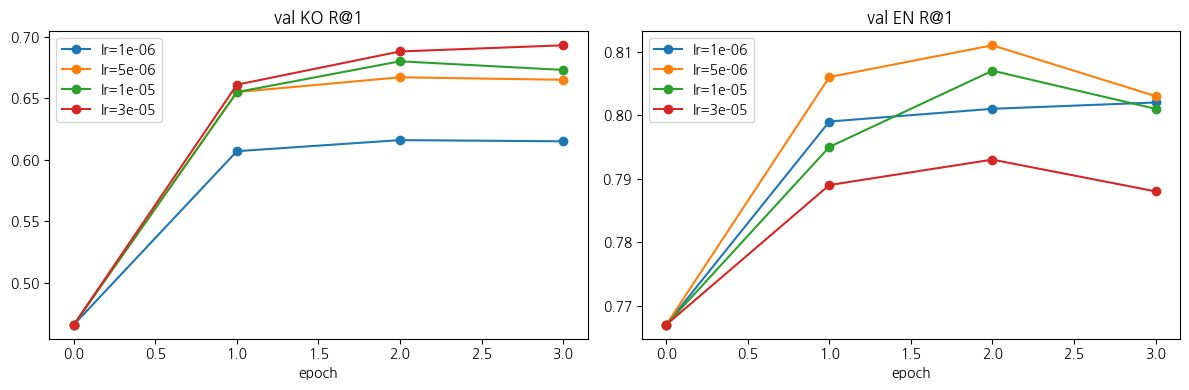

In [21]:
# [학습률 비교] lr 4개 × 3 epoch, validation 기준으로 비교 (약 35분)
# 끝난 학습률은 csv에 저장돼서 다시 실행하면 건너뜀
LRS = [1e-6, 5e-6, 1e-5, 3e-5]
EPOCHS = 3
SWEEP_PATH = f"{RESULT_DIR}/ft_lr_sweep.csv"

all_hist = pd.read_csv(SWEEP_PATH).to_dict("records") if os.path.exists(SWEEP_PATH) else []
done_lrs = {h["lr"] for h in all_hist if h["epoch"] == EPOCHS}

for lr in LRS:
    if lr in done_lrs:
        print(f"lr = {lr} 이미 완료, 건너뜀")
        continue
    print(f"\n===== lr = {lr} =====")
    all_hist = [h for h in all_hist if h["lr"] != lr]   # 중간에 끊긴 기록은 지우고 다시
    all_hist += train(lr, epochs=EPOCHS)
    pd.DataFrame(all_hist).to_csv(SWEEP_PATH, index=False)

sweep_df = pd.DataFrame(all_hist)
display(sweep_df.pivot(index="epoch", columns="lr", values="val_ko_R@1").round(3))
display(sweep_df.pivot(index="epoch", columns="lr", values="val_en_R@1").round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for lr in LRS:
    d = sweep_df[sweep_df["lr"] == lr]
    axes[0].plot(d["epoch"], d["val_ko_R@1"], marker="o", label=f"lr={lr}")
    axes[1].plot(d["epoch"], d["val_en_R@1"], marker="o", label=f"lr={lr}")
axes[0].set_title("val KO R@1"); axes[1].set_title("val EN R@1")
for ax in axes: ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout(); plt.savefig(f"{RESULT_DIR}/ft_lr_sweep.png", dpi=120, bbox_inches="tight"); plt.show()

In [23]:
# [최종 학습] validation 한국어 R@1이 가장 좋은 설정으로 다시 학습 → test에서 원래 모델과 비교 → 모델 저장
# 기본: val KO R@1이 가장 높은 설정 자동 선택 (3e-5, epoch 3이 나올 것)
best_row = sweep_df[sweep_df["epoch"] > 0].sort_values("val_ko_R@1", ascending=False).iloc[0]
BEST_LR, BEST_EP = float(best_row["lr"]), int(best_row["epoch"])
# 한국어·영어 균형형으로 하고 싶으면 위 두 줄 대신 아래 줄 사용
# BEST_LR, BEST_EP = 1e-5, 2
print("선택:", BEST_LR, BEST_EP)

final_hist = train(BEST_LR, epochs=BEST_EP)

def base_row(q):
    return recall_df[(recall_df["model"] == FT_NAME) & (recall_df["query"] == q)][["R@1", "R@5", "R@10"]].iloc[0].to_dict()

test_rows = [
    {"model": "siglip2-base (원래)",    "query": "KO", **base_row("KO caption_0")},
    {"model": "siglip2-base (원래)",    "query": "EN", **base_row("EN caption_0")},
    {"model": "siglip2-base (파인튜닝)", "query": "KO", **eval_recall(captions_ko, img_test)},
    {"model": "siglip2-base (파인튜닝)", "query": "EN", **eval_recall(captions["caption_0"], img_test)},
]
ft_test_df = pd.DataFrame(test_rows)
ft_test_df.to_csv(f"{RESULT_DIR}/ft_test_result_lr{BEST_LR}_ep{BEST_EP}.csv", index=False)
display(ft_test_df.round(3))

ft_model.save_pretrained(f"{FT_DIR}/siglip2-base-ko")
ft_proc.save_pretrained(f"{FT_DIR}/siglip2-base-ko")

선택: 3e-05 3
학습 파라미터: 85.7M
{'lr': 3e-05, 'epoch': 0, 'val_ko_R@1': 0.466, 'val_ko_R@5': 0.724, 'val_ko_R@10': 0.798, 'val_en_R@1': 0.767, 'val_en_R@5': 0.945, 'val_en_R@10': 0.976}


/tmp/ipykernel_978/528050895.py:69: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scaler.step(opt); scaler.update(); sched.step()


  ep1 step 100/468 loss 1.181
  ep1 step 200/468 loss 0.892
  ep1 step 300/468 loss 0.856
  ep1 step 400/468 loss 0.791
epoch 1 (173s): {'val_ko_R@1': 0.646, 'val_ko_R@10': 0.947, 'val_en_R@1': 0.782, 'val_en_R@10': 0.984}
  ep2 step 100/468 loss 0.568
  ep2 step 200/468 loss 0.548
  ep2 step 300/468 loss 0.515
  ep2 step 400/468 loss 0.517
epoch 2 (172s): {'val_ko_R@1': 0.695, 'val_ko_R@10': 0.959, 'val_en_R@1': 0.791, 'val_en_R@10': 0.982}
  ep3 step 100/468 loss 0.366
  ep3 step 200/468 loss 0.374
  ep3 step 300/468 loss 0.366
  ep3 step 400/468 loss 0.359
epoch 3 (172s): {'val_ko_R@1': 0.687, 'val_ko_R@10': 0.956, 'val_en_R@1': 0.788, 'val_en_R@10': 0.985}


,model,query,R@1,R@5,R@10
0,siglip2-base (원래),KO,0.450,0.693,0.779
1,siglip2-base (원래),EN,0.769,0.948,0.982
2,siglip2-base (파인튜닝),KO,0.680,0.893,0.940
3,siglip2-base (파인튜닝),EN,0.776,0.958,0.982


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['/content/drive/MyDrive/DRAG/week5/finetune/siglip2-base-ko/processor_config.json']

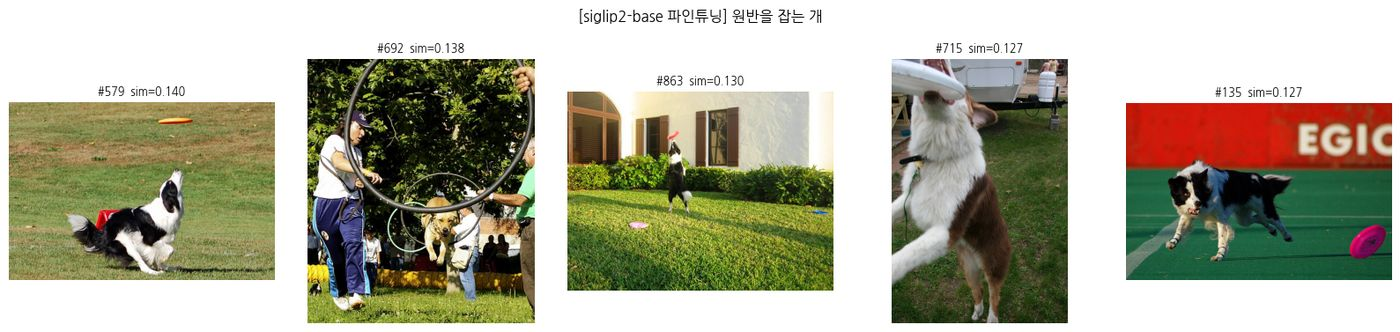

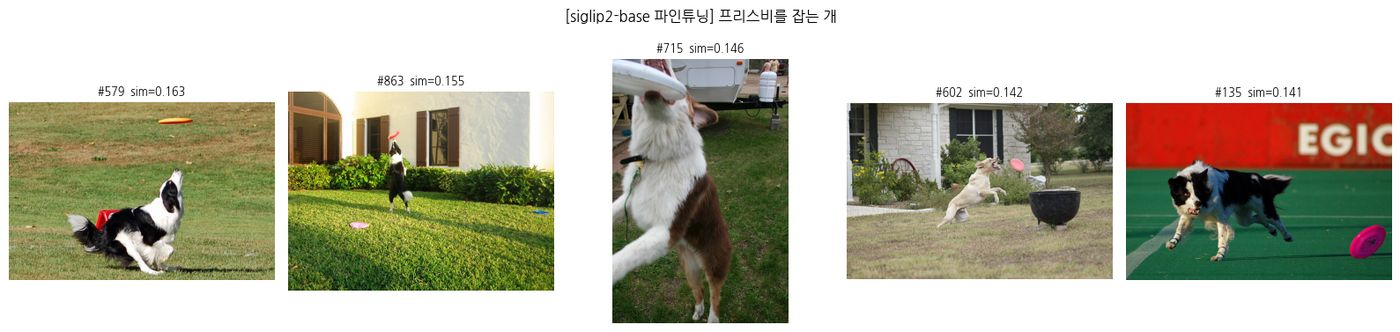

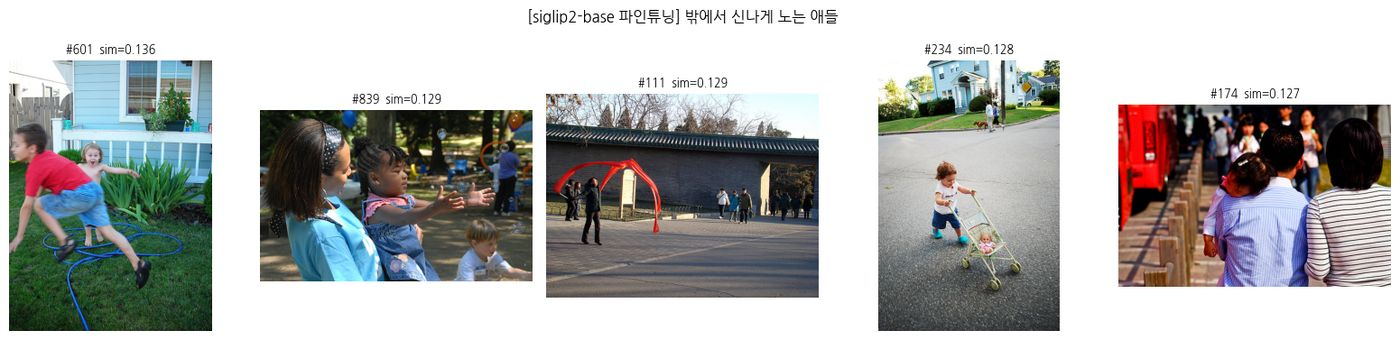

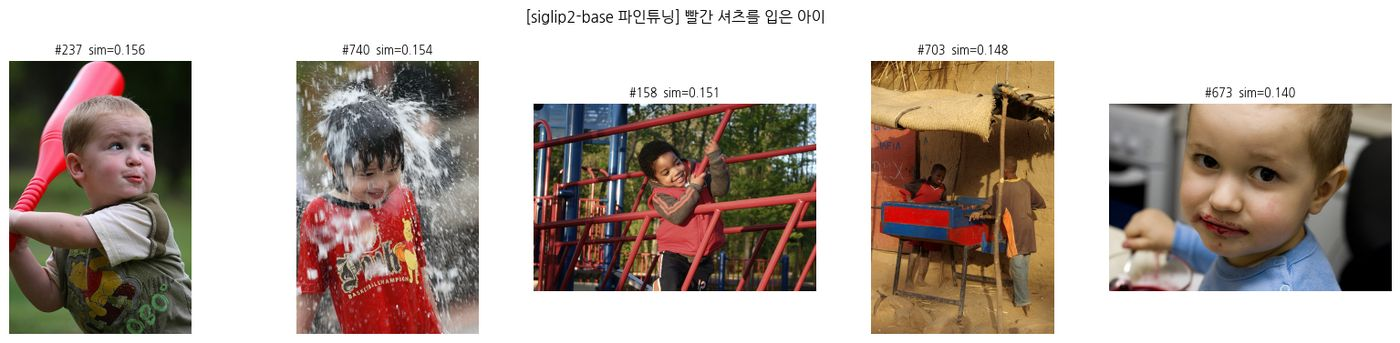

In [24]:
# 파인튜닝 모델로 한국어 검색 결과 확인 (원반/프리스비, 구어체, 색상 질의)
@torch.no_grad()
def ft_show(query, k=5):
    with torch.autocast("cuda", dtype=torch.float16):
        q = encode_text([query]).cpu().numpy()
    sim = (q @ img_test.T)[0]
    ids = np.argsort(-sim)[:k]
    fig, axes = plt.subplots(1, k, figsize=(3.2 * k, 3.8))
    for ax, i in zip(axes, ids):
        ax.imshow(images[int(i)]); ax.set_title(f"#{int(i)}  sim={sim[i]:.3f}", fontsize=9); ax.axis("off")
    fig.suptitle(f"[siglip2-base 파인튜닝] {query}", fontsize=12)
    plt.tight_layout()
    fig.savefig(f"{RESULT_DIR}/ft_search_{query.replace(' ', '_')[:40]}.png", dpi=120, bbox_inches="tight")
    plt.show()

ft_model.eval()
for q in ["원반을 잡는 개", "프리스비를 잡는 개", "밖에서 신나게 노는 애들", "빨간 셔츠를 입은 아이"]:
    ft_show(q)

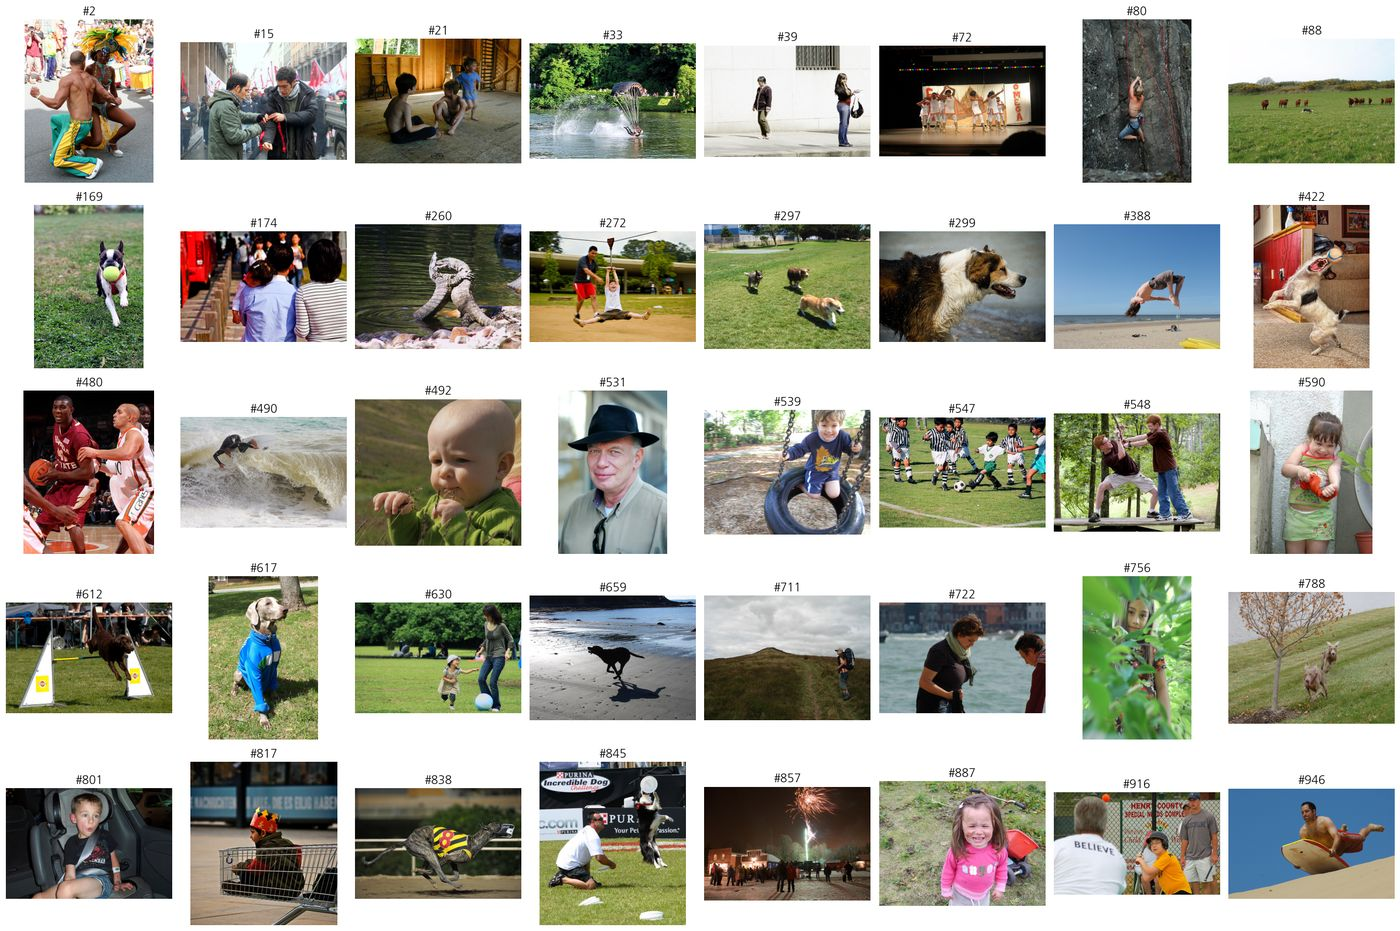

human_queries = {
    2: "",
    15: "",
    21: "",
    33: "",
    39: "",
    72: "",
    80: "",
    88: "",
    169: "",
    174: "",
    260: "",
    272: "",
    297: "",
    299: "",
    388: "",
    422: "",
    480: "",
    490: "",
    492: "",
    531: "",
    539: "",
    547: "",
    548: "",
    590: "",
    612: "",
    617: "",
    630: "",
    659: "",
    711: "",
    722: "",
    756: "",
    788: "",
    801: "",
    817: "",
    838: "",
    845: "",
    857: "",
    887: "",
    916: "",
    946: "",
}


In [25]:
# [재평가 준비] test 이미지 40장을 무작위로 뽑아 번호와 함께 보여줌
# 번역 캡션이 아닌, 사진만 보고 새로 쓴 한국어 질의로 평가하기 위함
HUMAN_N = 40   # 쓰기 부담되면 30으로 줄여도 됨
rng = np.random.default_rng(0)
human_ids = sorted(rng.choice(N_IMAGES, HUMAN_N, replace=False).tolist())

fig, axes = plt.subplots(5, 8, figsize=(24, 16))
for ax, i in zip(axes.flat, human_ids):
    ax.imshow(images[i]); ax.set_title(f"#{i}", fontsize=14); ax.axis("off")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/human_query_images.png", dpi=80, bbox_inches="tight")
plt.show()

# 아래 출력을 복사해서 셀 C2에 붙여넣고 "" 안을 채우기
print("human_queries = {")
for i in human_ids:
    print(f'    {i}: "",')
print("}")

def big(i):   # 사진이 작아서 안 보이면 big(번호)로 크게 보기
    plt.figure(figsize=(6, 6)); plt.imshow(images[i]); plt.title(f"#{i}"); plt.axis("off"); plt.show()

In [26]:
# 사진 번호별 한국어 검색어 (영어 캡션을 보지 않고 사진만 보고 작성)
human_queries = {
    2: "깃털 장식 의상 입고 퍼레이드에서 춤추는 사람들",
    15: "시위하는 거리에서 빨간 끈 주고받는 남자 둘",
    21: "나무 창고 바닥에서 노는 웃통 벗은 남자애들",
    33: "물 위로 물보라 일으키며 낙하산 타는 사람",
    39: "하얀 벽 앞에 멀찍이 떨어져 서 있는 두 사람",
    72: "무대 위에서 단체로 춤 공연하는 아이들",
    80: "로프 매고 바위 절벽 맨손으로 오르는 사람",
    88: "넓은 초원에 소 떼랑 개 한 마리",
    169: "테니스공 물고 잔디밭 달려오는 강아지",
    174: "사람 많은 거리에서 아빠 어깨에 기댄 아이 뒷모습",
    260: "물가에서 엉켜 싸우는 도마뱀 두 마리",
    272: "놀이터에서 줄 매달려 타는 아이랑 옆에 남자",
    297: "잔디밭에서 뛰어다니는 강아지 세 마리",
    299: "털 젖은 개 옆모습 클로즈업",
    388: "해변에서 공중제비 도는 남자",
    422: "집 안에서 공 잡으려고 펄쩍 뛰는 개",
    480: "빨간 유니폼 입고 드리블하는 농구 선수",
    490: "큰 파도 위에서 서핑하는 사람",
    492: "풀 뜯어서 입에 넣는 아기",
    531: "검은 중절모 쓴 할아버지 얼굴",
    539: "타이어 그네 타면서 웃는 남자애",
    547: "줄무늬 유니폼 입고 축구하는 꼬마들",
    548: "숲속 나무 데크에서 밧줄 잡고 노는 남자애 둘",
    590: "초록 옷 입고 빨간 장난감 들고 있는 여자아이",
    612: "장애물 넘는 갈색 개",
    617: "파란 옷 입혀놓은 회색 개",
    630: "공원에서 엄마랑 공 차는 꼬마",
    659: "물 빠진 모래사장 달리는 검은 개 그림자",
    711: "흐린 날 언덕길 걷는 배낭 멘 사람",
    722: "강가에서 목도리 두른 여자",
    756: "나뭇잎 사이로 얼굴 내민 여자애",
    788: "비탈진 잔디밭 나무 옆에서 뛰는 개 두 마리",
    801: "카시트에 앉아서 놀란 표정 짓는 남자애",
    817: "왕관 쓰고 쇼핑카트에 탄 애",
    838: "번호 조끼 입고 경주하는 그레이하운드",
    845: "개 묘기 대회에서 원반 잡으려고 뛰는 개",
    857: "밤에 불꽃놀이 구경하는 사람들",
    887: "분홍 옷 입고 울상 짓는 여자아이",
    916: "철망 앞에서 헬멧 쓰고 야구하는 아이",
    946: "모래언덕에서 보드 타고 날아오르는 남자",
}

In [27]:
# [재평가] 새로 쓴 질의 40개로 원래 base / 파인튜닝 base / so400m 비교
# 질의별로 정답 사진이 몇 위였는지도 같이 저장
human_queries = {int(k): v.strip() for k, v in human_queries.items() if v.strip()}
json.dump(human_queries, open(f"{FT_DIR}/human_queries.json", "w", encoding="utf-8"), ensure_ascii=False, indent=1)
hq_ids = list(human_queries.keys())
hq_texts = list(human_queries.values())
print("평가할 질의 수:", len(hq_texts))

def recall_ids(sim, gt_ids, ks=KS):
    topk = np.argsort(-sim, axis=1)[:, :max(ks)]
    gt = np.asarray(gt_ids)[:, None]
    return {f"R@{k}": float((topk[:, :k] == gt).any(axis=1).mean()) for k in ks}

def gt_rank(sim, gt_ids):
    return [int((sim[r] > sim[r, g]).sum()) + 1 for r, g in enumerate(gt_ids)]

@torch.no_grad()
def ft_encode(texts):
    ft_model.eval()
    with torch.autocast("cuda", dtype=torch.float16):
        return encode_text(texts).cpu().numpy()

sims = {}

# 1) 파인튜닝 모델
sims["siglip2-base 파인튜닝"] = ft_encode(hq_texts) @ img_test.T

# 2) 원래 모델: 텍스트 쪽만 학습 전 상태로 잠깐 되돌렸다가 다시 복구
ft_state = {k: v.detach().clone().cpu() for k, v in ft_model.state_dict().items() if not k.startswith("vision_model")}
ft_model.load_state_dict(init_state, strict=False)
sims["siglip2-base 원래"] = ft_encode(hq_texts) @ img_test.T
ft_model.load_state_dict(ft_state, strict=False)
del ft_state; gc.collect()

# 3) so400m (학습 없음)
if "siglip2-so400m" in indexes:
    load_model("siglip2-so400m")
    so_img = indexes["siglip2-so400m"].reconstruct_n(0, indexes["siglip2-so400m"].ntotal)
    sims["siglip2-so400m 원래"] = embed_texts(hq_texts) @ so_img.T

order = [k for k in ["siglip2-base 원래", "siglip2-base 파인튜닝", "siglip2-so400m 원래"] if k in sims]

human_df = pd.DataFrame([{"model": m, **recall_ids(sims[m], hq_ids)} for m in order])
human_df.to_csv(f"{RESULT_DIR}/recall_human_queries.csv", index=False)
print("=== 사진 보고 쓴 한국어 질의 Recall@K ===")
display(human_df.round(3))

# 질의별 정답 순위 (1이면 1등으로 찾음)
rank_df = pd.DataFrame({"id": hq_ids, "query": hq_texts, **{m: gt_rank(sims[m], hq_ids) for m in order}})
rank_df.to_csv(f"{RESULT_DIR}/rank_human_queries.csv", index=False)
print("=== 질의별 정답 순위 ===")
display(rank_df)

평가할 질의 수: 40


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

loaded: google/siglip2-so400m-patch14-384
=== 사진 보고 쓴 한국어 질의 Recall@K ===


,model,R@1,R@5,R@10
0,siglip2-base 원래,0.625,0.975,1.0
1,siglip2-base 파인튜닝,0.675,0.950,1.0
2,siglip2-so400m 원래,0.725,0.925,1.0


=== 질의별 정답 순위 ===


,id,query,siglip2-base 원래,siglip2-base 파인튜닝,siglip2-so400m 원래
0,2,깃털 장식 의상 입고 퍼레이드에서 춤추는 사람들,2,1,2
1,15,시위하는 거리에서 빨간 끈 주고받는 남자 둘,1,1,1
2,21,나무 창고 바닥에서 노는 웃통 벗은 남자애들,1,1,1
3,33,물 위로 물보라 일으키며 낙하산 타는 사람,1,8,1
4,39,하얀 벽 앞에 멀찍이 떨어져 서 있는 두 사람,2,4,1
5,72,무대 위에서 단체로 춤 공연하는 아이들,4,1,9
6,80,로프 매고 바위 절벽 맨손으로 오르는 사람,3,3,6
7,88,넓은 초원에 소 떼랑 개 한 마리,1,1,1
8,169,테니스공 물고 잔디밭 달려오는 강아지,3,2,1
9,174,사람 많은 거리에서 아빠 어깨에 기댄 아이 뒷모습,1,1,1


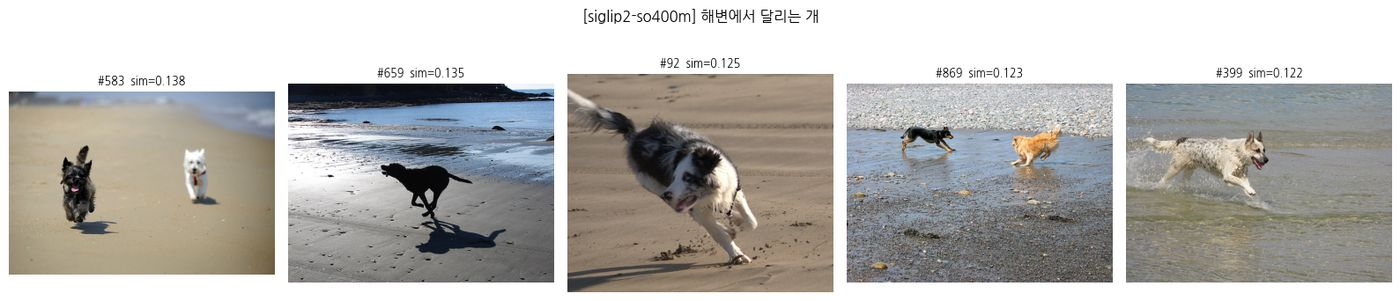

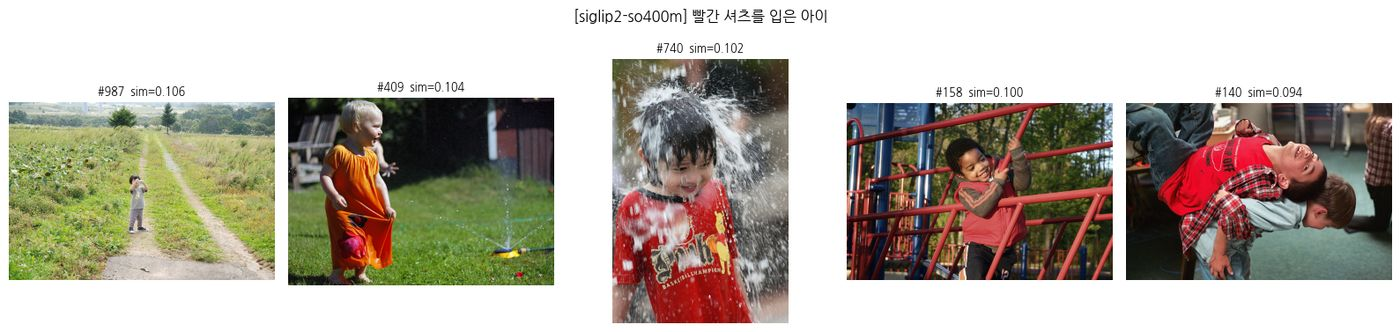

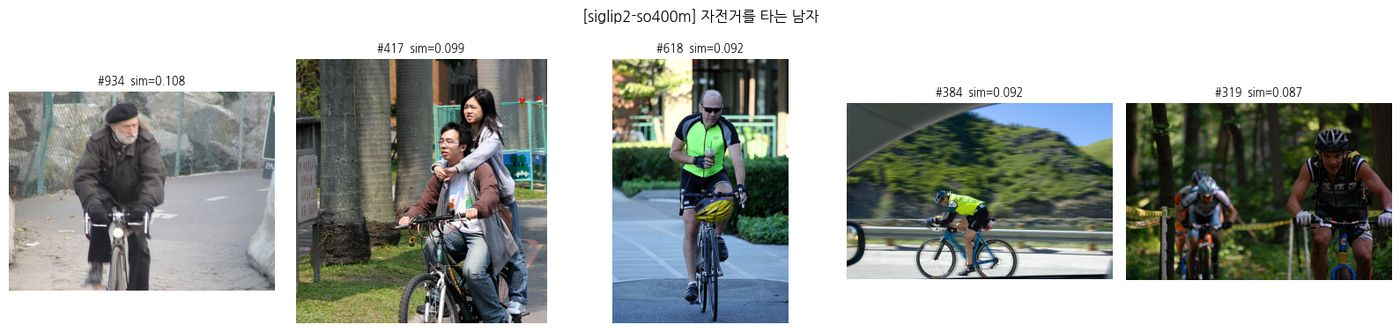

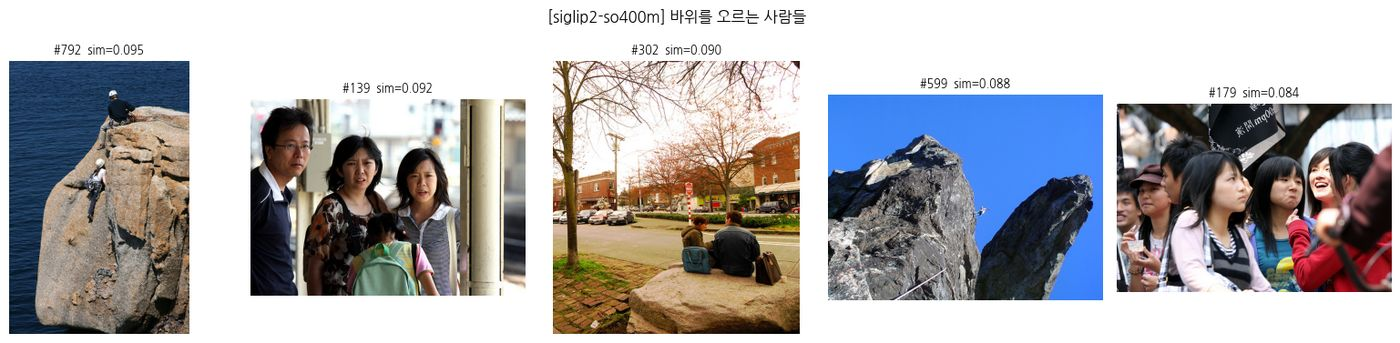

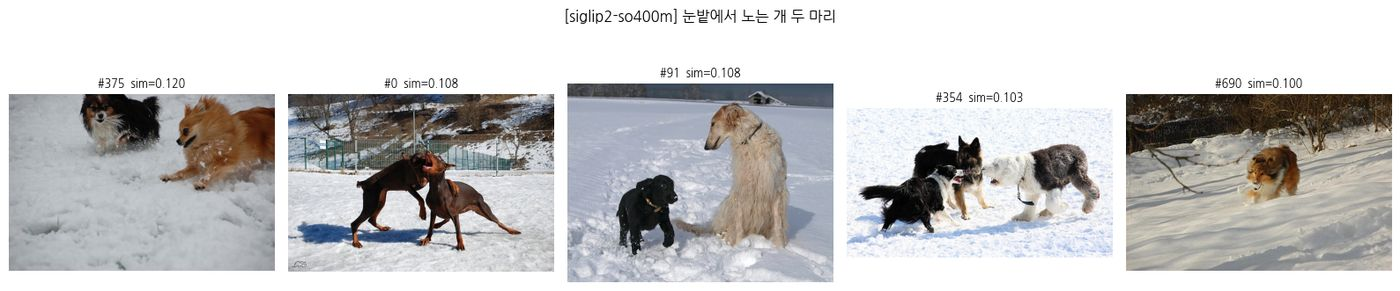

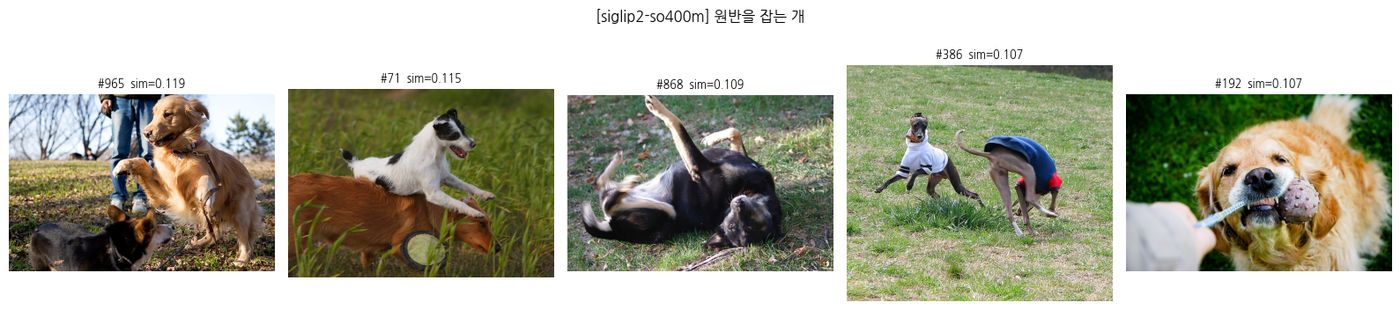

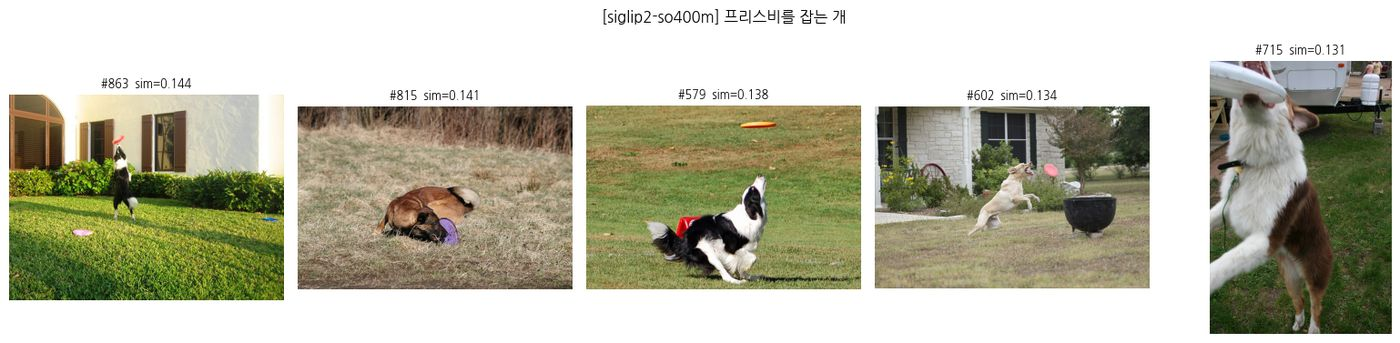

원반: 0 / 프리스비: 231
A man eyes the ground as he comes in for a landing from parasailing . → 한 남자가 낙하산에서 착륙하기 위해 착륙하는 동안 바닥을 바라보고 있습니다 .
The people in the red parasail are gliding over the water . → 빨간색 낙하산에 있는 사람들은 물 위에 달리고 있습니다 .
A man parasails on the water . → 한 남자가 물 위에 낙하산을 타고 다니고 있습니다 .
A man is parasailing in the ocean with a clear sky . → 한 남자가 맑은 하늘로 바다에서 낙하산을 타고 있습니다 .
A man parasails on the choppy sea , with a board on his feet to catch the waves . → 한 남자가 파도를 잡기 위해 발에 보드를 들고 붐비는 바다에서 낙하산을 타고
A person attached to a parasail and wearing equipment on his feet is suspended in midair over a snowy landscape , while silhouetted against a sunny , blue sky . → 낙하산에 부착되어 발에 장비를 착용한 사람은 눈이 내린 풍경 위에 공중에서 매달리고 있으며 ,
A person parasailing on a wave . → 물결을 타고 낙하산을 타는 사람 .
A person is parasailing over water , with other parasailors close behind him . → 한 사람이 물 위에 낙하산을 타고 있고 다른 낙하산이 그 뒤에 있다 .
A yellow parasail is in the air . → 공중에는 황색 낙하산이 있습니다 .
A small parasail . → 작은 낙하산 .
Man parasails a

In [28]:
# [추가] 한국어 질의 검색 결과 + 발표 질문 대비 확인
# - 영어 질의와 같은 뜻의 한국어 질의, 원반 vs 프리스비 비교
# - 학습 데이터 번역에 원반/프리스비가 몇 번 나오는지, parasail이 어떻게 번역됐는지
load_model(BEST)
index = indexes[BEST]

ko_queries = [
    "해변에서 달리는 개",
    "빨간 셔츠를 입은 아이",
    "자전거를 타는 남자",
    "바위를 오르는 사람들",
    "눈밭에서 노는 개 두 마리",
]
for q in ko_queries:
    show_results(q)

# 단어 선택 비교: 원반 vs 프리스비
for q in ["원반을 잡는 개", "프리스비를 잡는 개"]:
    show_results(q)

# 질문 대비: 학습 데이터에서 원반/프리스비 등장 횟수
print("원반:", sum("원반" in k for k in train_ko), "/ 프리스비:", sum("프리스비" in k for k in train_ko))

# 질문 대비: parasail이 어떻게 번역됐는지
for en, ko in zip(train_en, train_ko):
    if "parasail" in en.lower():
        print(en, "→", ko)